
La potencia $P$, generada por un molino de agua a velocidad $V$, puede ser modelada por el sistema
\[
\begin{aligned}
\frac{dP}{dt} &= -\,\alpha P + P\,V,\\[0.3em]
\frac{dV}{dt} &= 1 - \beta V - P^{2},
\end{aligned}
\]
donde $\alpha$ y $\beta$ son constantes positivas. Describir el comportamiento cualitativo del sistema cuando $\alpha$ y $\beta$ varían y dar interpretaciones físicas de los resultados.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

In [4]:
alphas = []
betas = []

P, V = sp.symbols('P V')
a, b = sp.symbols('a b')

eq1 = sp.Eq(-a*P + P*V, 0)
eq2  = sp.Eq(1 - b*V - P**2, 0)

equilibrio = sp.solve((eq1, eq2), (P, V))
print(f'Equilibrio: {equilibrio}')

# funciones del sistema

f = -a*P + P*V
g = 1 - b*V - P**2

# campo vectorial 

F = sp.Matrix([f,g])

# jacobiano

J = F.jacobian([P, V])
sp.pprint(J)

# Autovalores

avals = J.eigenvals()
print(f'Autovalores: {avals}')
sp.pprint(avals)

Equilibrio: [(0, 1/b), (-sqrt(-a*b + 1), a), (sqrt(-a*b + 1), a)]
⎡V - a  P ⎤
⎢         ⎥
⎣-2⋅P   -b⎦
Autovalores: {V/2 - a/2 - b/2 - sqrt(-8*P**2 + V**2 - 2*V*a + 2*V*b + a**2 - 2*a*b + b**2)/2: 1, V/2 - a/2 - b/2 + sqrt(-8*P**2 + V**2 - 2*V*a + 2*V*b + a**2 - 2*a*b + b**2)/2: 1}
⎧               _______________________________________________                ↪
⎪              ╱      2    2                    2            2                 ↪
⎨V   a   b   ╲╱  - 8⋅P  + V  - 2⋅V⋅a + 2⋅V⋅b + a  - 2⋅a⋅b + b       V   a   b  ↪
⎪─ - ─ - ─ - ──────────────────────────────────────────────────: 1, ─ - ─ - ─  ↪
⎩2   2   2                           2                              2   2   2  ↪

↪      _______________________________________________   ⎫
↪     ╱      2    2                    2            2    ⎪
↪   ╲╱  - 8⋅P  + V  - 2⋅V⋅a + 2⋅V⋅b + a  - 2⋅a⋅b + b     ⎬
↪ + ──────────────────────────────────────────────────: 1⎪
↪                           2                            ⎭


In [ ]:
def sistema(t, estado, a, b):
    p, v = estado
    return [-a * p + p*v, 1 - b*v - p**2]

alphas = []
betas = []

x_vals = np.linspace(-2, 2, 20)
y_vals = np.linspace(-10, 10, 20)
P, V = np.meshgrid(x_vals, y_vals)



In [5]:
import sympy as sp

# variables
P, V = sp.symbols('P V')
a, b = sp.symbols('a b', real=True)

# sistema
f = -a*P + P*V
g = 1 - b*V - P**2

# vector campo
F = sp.Matrix([f, g])

# jacobiano
J = F.jacobian([P, V])

print("Jacobiano general:")
sp.pprint(J)
print()

# equilibrios simbólicos
equilibrios = sp.solve((sp.Eq(f, 0), sp.Eq(g, 0)), (P, V), dict=True)

print("Equilibrios simbólicos:")
for eq in equilibrios:
    sp.pprint(eq)
print()

# valores a probar
valores = [
    (0.5, 0.5),
    (1, 0.5),
    (1, 1),
    (2, 1),
    (0.2, 3)
]

for aval, bval in valores:
    print("="*50)
    print(f"a = {aval}, b = {bval}")
    
    # sustituimos parámetros
    equilibrios_ab = []
    for eq in equilibrios:
        eq_num = {var: sp.simplify(expr.subs({a: aval, b: bval})) for var, expr in eq.items()}
        equilibrios_ab.append(eq_num)
    
    print("\nEquilibrios:")
    for i, eq in enumerate(equilibrios_ab, start=1):
        print(f"\nEquilibrio {i}:")
        sp.pprint(eq)
        
        # evaluar jacobiano en ese equilibrio
        J_eq = J.subs({a: aval, b: bval, P: eq[P], V: eq[V]})
        print("Jacobiano evaluado:")
        sp.pprint(sp.simplify(J_eq))
        
        # autovalores
        eigs = sp.simplify(J_eq).eigenvals()
        print("Autovalores:")
        sp.pprint(eigs)

Jacobiano general:
⎡V - a  P ⎤
⎢         ⎥
⎣-2⋅P   -b⎦

Equilibrios simbólicos:
⎧         1⎫
⎨P: 0, V: ─⎬
⎩         b⎭
⎧      __________      ⎫
⎨P: -╲╱ -a⋅b + 1 , V: a⎬
⎩                      ⎭
⎧     __________      ⎫
⎨P: ╲╱ -a⋅b + 1 , V: a⎬
⎩                     ⎭

a = 0.5, b = 0.5

Equilibrios:

Equilibrio 1:
{P: 0, V: 2.0}
Jacobiano evaluado:
⎡1.5   0  ⎤
⎢         ⎥
⎣ 0   -0.5⎦
Autovalores:
{-0.5: 1, 1.5: 1}

Equilibrio 2:
{P: -0.866025403784439, V: 0.5}
Jacobiano evaluado:
⎡       0          -0.866025403784439⎤
⎢                                    ⎥
⎣1.73205080756888         -0.5       ⎦
Autovalores:
{-0.25 - 1.19895788082818⋅ⅈ: 1, -0.25 + 1.19895788082818⋅ⅈ: 1}

Equilibrio 3:
{P: 0.866025403784439, V: 0.5}
Jacobiano evaluado:
⎡        0          0.866025403784439⎤
⎢                                    ⎥
⎣-1.73205080756888        -0.5       ⎦
Autovalores:
{-0.25 - 1.19895788082818⋅ⅈ: 1, -0.25 + 1.19895788082818⋅ⅈ: 1}
a = 1, b = 0.5

Equilibrios:

Equilibrio 1:
{P: 0, V: 2.0}
Jacobia

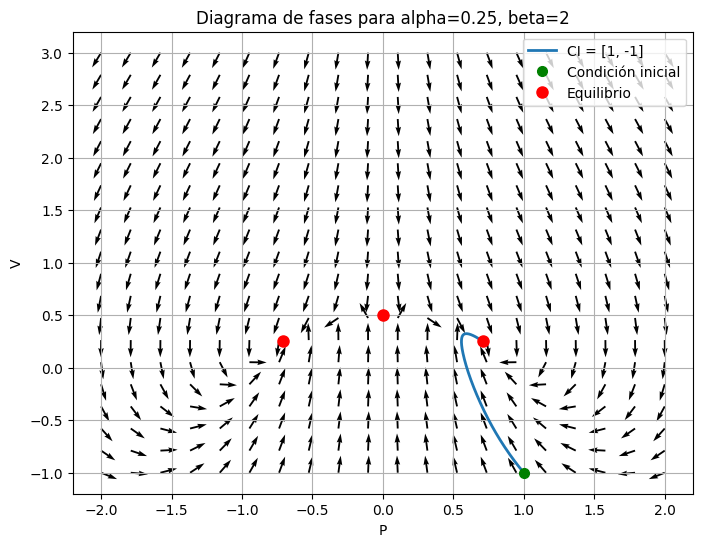

In [13]:
# -------------------------------
# Sistema
# -------------------------------
def sistema(t, estado, alpha, beta):
    P, V = estado
    return [-alpha*P + P*V, 1 - beta*V - P**2]

# -------------------------------
# Parámetros
# -------------------------------
alpha_val = 0.25
beta_val = 2

estado_inicial = [1,-1]

# -------------------------------
# Grilla
# -------------------------------
x_vals = np.linspace(-2, 2, 20)
y_vals = np.linspace(-1, 3, 20)
P_grid, V_grid = np.meshgrid(x_vals, y_vals)

dP = -alpha_val*P_grid + P_grid*V_grid
dV = 1 - beta_val*V_grid - P_grid**2

norma = np.sqrt(dP**2 + dV**2)
norma[norma == 0] = 1
dP_normalizado = dP / norma
dV_normalizado = dV / norma

# -------------------------------
# Trayectoria
# -------------------------------
sol = solve_ivp(
    sistema,
    [0, 10],
    estado_inicial,
    args=(alpha_val, beta_val),
    t_eval=np.linspace(0, 10, 1000)
)

# -------------------------------
# Equilibrios con SymPy
# -------------------------------
P, V = sp.symbols('P V', real=True)
alpha, beta = sp.symbols('alpha beta', real=True)

eq1 = sp.Eq(-alpha*P + P*V, 0)
eq2 = sp.Eq(1 - beta*V - P**2, 0)

equilibrios = sp.solve((eq1, eq2), (P, V), dict=True)

equilibrios_num = []
for eq in equilibrios:
    P_eq = sp.simplify(eq[P].subs({alpha: alpha_val, beta: beta_val}))
    V_eq = sp.simplify(eq[V].subs({alpha: alpha_val, beta: beta_val}))
    
    P_eq = complex(P_eq.evalf())
    V_eq = complex(V_eq.evalf())
    
    if abs(P_eq.imag) < 1e-10 and abs(V_eq.imag) < 1e-10:
        equilibrios_num.append((P_eq.real, V_eq.real))

# -------------------------------
# Gráfico
# -------------------------------
plt.figure(figsize=(8, 6))
plt.quiver(P_grid, V_grid, dP_normalizado, dV_normalizado)

plt.plot(sol.y[0], sol.y[1], linewidth=2, label=f'CI = {estado_inicial}')
plt.plot(estado_inicial[0], estado_inicial[1], 'go', markersize=7, label='Condición inicial')

for i, (P_eq, V_eq) in enumerate(equilibrios_num):
    if i == 0:
        plt.plot(P_eq, V_eq, 'ro', markersize=8, label='Equilibrio')
    else:
        plt.plot(P_eq, V_eq, 'ro', markersize=8)

plt.xlabel('P')
plt.ylabel('V')
plt.title(f'Diagrama de fases para alpha={alpha_val}, beta={beta_val}')
plt.grid(True)
plt.legend()
plt.show()